<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">

## Project: Fake News Classifier – NLP Challenge (Week 30)

**Goal**: Build a binary classifier that predicts whether a news headline is real (1) or fake (0).  
**Data**: dataset/data.csv (training data) with columns: label, title, text, subject, date.  
**Validation**: dataset/validation_data.csv (labels are 2, to be replaced by 0/1 predictions).  

## Workflow Overview

1. **Imports & NLTK Setup** – load all required libraries and download NLTK data.
2. **Load Data** – read training and validation CSV files.
3. **EDA** – inspect missing values, label distribution, subject counts, text length.
4. **Text Preprocessing** – clean, tokenise, remove stopwords, POS‑aware lemmatisation.
5. **Feature Engineering** – create three feature columns: title_only, text_only, combined.
6. **Train/Test Split** – stratified 70/30 split, preserving class balance.
7. **Define Model Templates** – list of classifiers with hyperparameter grids.
8. **Expand Configurations** – use ParameterGrid to flatten all hyperparameter combinations.
9. **Evaluate Configurations with Cross‑Validation** – for each (feature, config) pair, perform 5‑fold cross‑validation on the training set; return mean CV F1 score.
10. **Select Best Configuration** – choose the one with the highest mean CV F1.
11. **Train Final Model** – retrain on the full training set with the best hyperparameters.
12. **Evaluate on Test Set** – compute final accuracy, F1, classification report, confusion matrix.
13. **Feature Importance** – if the best model is linear, extract top coefficients.
14. **Predict on Validation Set** – generate submission CSV.
15. **Cross‑validate Final Pipeline** – estimate generalisation performance (optional).

</div>

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
1- Load all necessary libraries for data handling, visualization, text processing, and machine learning.
</div>

In [2]:
# ----- Libraries -----
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
import pickle

# ----- Scikit‑learn -----
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score
)
from itertools import product
from sklearn.model_selection import cross_val_score

# ----- Text Processing -----
import nltk
from nltk.tokenize import word_tokenize          # splits text into words
from nltk.corpus import stopwords                # common words to remove
from nltk import pos_tag                         # part‑of‑speech tagger
from nltk.stem import WordNetLemmatizer          # reduces words to root form



# ----- Utilities -----
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources (run once)
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')
# nltk.download('averaged_perceptron_tagger')   # for POS tagging

print("All imports successful.")

All imports successful.


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
2- Load the data: 

Purpose: Read the training and validation CSV files.

Why: We need the raw data to begin analysis and later generate predictions.
</div>

In [3]:
# Load datasets 
data = pd.read_csv('../dataset/data.csv')
validation = pd.read_csv('../dataset/validation_data.csv')

print("Training data shape:", data.shape)
print("Validation data shape:", validation.shape)
display("data.head()", data.head())
display("validation_data.head()",validation.head())

Training data shape: (39942, 5)
Validation data shape: (4956, 5)


'data.head()'

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


'validation_data.head()'

,label,title,text,subject,date
0,2,UK's May 'receiving regular updates' on London...,LONDON (Reuters) - British Prime Minister Ther...,worldnews,"September 15, 2017"
1,2,UK transport police leading investigation of L...,LONDON (Reuters) - British counter-terrorism p...,worldnews,"September 15, 2017"
2,2,Pacific nations crack down on North Korean shi...,WELLINGTON (Reuters) - South Pacific island na...,worldnews,"September 15, 2017"
3,2,Three suspected al Qaeda militants killed in Y...,"ADEN, Yemen (Reuters) - Three suspected al Qae...",worldnews,"September 15, 2017"
4,2,Chinese academics prod Beijing to consider Nor...,BEIJING (Reuters) - Chinese academics are publ...,worldnews,"September 15, 2017"


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
3- EDA: Basic Info and Missing Values.

Purpose: Inspect data quality, class balance, subject distribution, and text length patterns.

Why: Understanding the data helps guide preprocessing and model selection.
</div>

In [4]:
# missing values, non-null counts and data types
print('data.isnull().sum()=', data.isnull().sum())
print("Training data info:")
data.info()

print('validation.isnull().sum()=', validation.isnull().sum())
print("\nValidation data info:")
validation.info()

data.isnull().sum()= label      0
title      0
text       0
subject    0
date       0
dtype: int64
Training data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39942 entries, 0 to 39941
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    39942 non-null  int64 
 1   title    39942 non-null  object
 2   text     39942 non-null  object
 3   subject  39942 non-null  object
 4   date     39942 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.5+ MB
validation.isnull().sum()= label      0
title      0
text       0
subject    0
date       0
dtype: int64

Validation data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4956 entries, 0 to 4955
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    4956 non-null   int64 
 1   title    4956 non-null   object
 2   text     4956 non-null   object
 3   subject  4956 non-null   object
 4   dat

## Output: No missing values

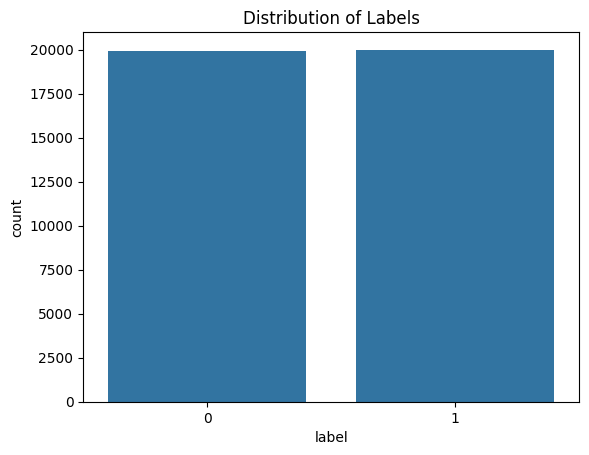

In [5]:
# Label distribution
sns.countplot(x='label', data=data)
plt.title('Distribution of Labels')
plt.show()

## Output: Label distribution: approximately 50/50 (balanced). 

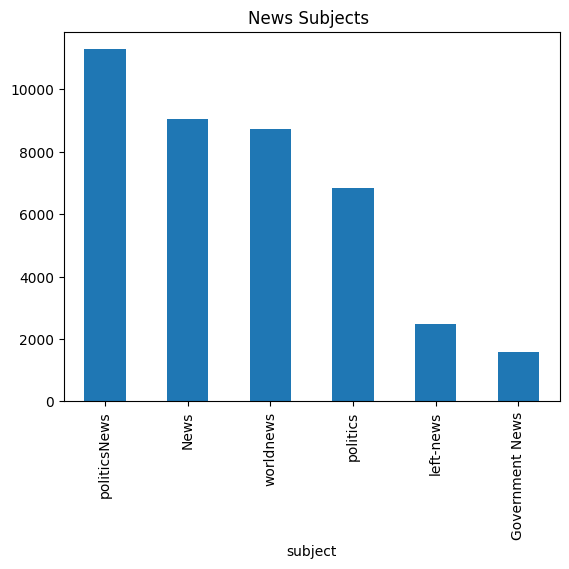

In [6]:
# Subject distribution
data['subject'].value_counts().plot(kind='bar')
plt.title('News Subjects ')
plt.show()

## Output: Subject distribution – politicsNews dominates

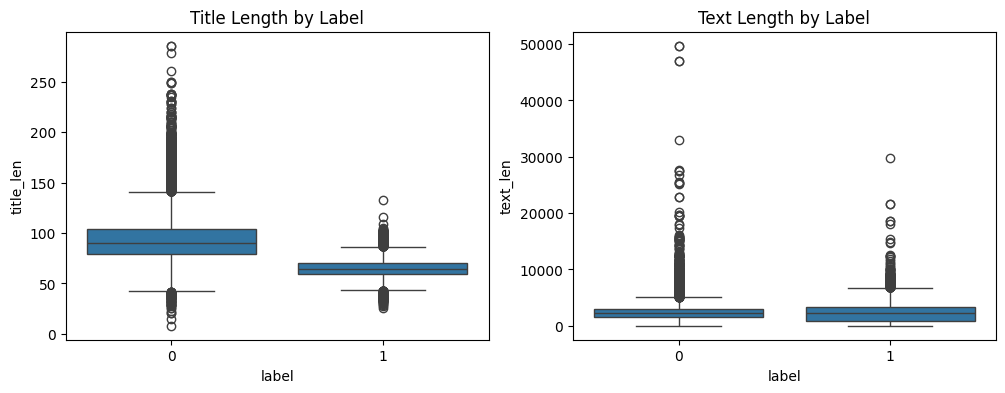

In [7]:
data['title_len'] = data['title'].apply(len)
data['text_len'] = data['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='label', y='title_len', data=data, ax=axes[0])
axes[0].set_title('Title Length by Label')
sns.boxplot(x='label', y='text_len', data=data, ax=axes[1])
axes[1].set_title('Text Length by Label')
plt.show()

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
4- Text Preprocessing Function

Purpose: Clean and lemmatize text with part‑of‑speech (POS) awareness for better normalization.

Why: Removing punctuation/digits, lowercasing, and removing stopwords reduce noise. POS‑aware lemmatization yields root forms like “run” for “running” and “ran”, reducing feature space and improving generalization
</div>

In [8]:
# Constants defined once for performance
STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

# Map NLTK POS tags to WordNet tags (first letter)
WORDNET_TAG_MAP = {'J': 'a', 'V': 'v', 'R': 'r'}  # adjective, verb, adverb; default 'n' for noun

# ----- POS‑aware lemmatization function -----
def clean_text(text: str) -> str:
    """
    Cleans and lemmatizes text with POS awareness.
    
    Steps:
      1. Lowercase.
      2. Tokenize.
      3. Remove non‑alphabetic characters from each token.
      4. Remove stopwords and empty tokens.
      5. POS tag each token.
      6. Lemmatize using WordNet's POS mapping.
      7. Return space‑joined tokens.
    """
    # 1. Lowercase.
    text = text.lower()

    # 2. Tokenize.
    tokens = word_tokenize(text)

    # 3. Remove non‑alphabetic characters from each token (e.g., punctuation, digits)
    tokens = [re.sub(r'[^a-zA-Z]', '', t) for t in tokens]      # keep only letters

    # 4. Filter out stopwords and empty strings
    tokens = [t for t in tokens if t and t not in STOP_WORDS]

    # 5. POS tagging – gives each token a grammatical category
    tagged = pos_tag(tokens)

    # 6. Lemmatize with POS mapping
    lemmatized = [
        LEMMATIZER.lemmatize(word, WORDNET_TAG_MAP.get(tag[0], 'n'))
        for word, tag in tagged
    ]
    return ' '.join(lemmatized)

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
5- Create Feature Columns

Purpose: Generate three feature sets to compare performance.

Why: We don’t know which source gives better signal; benchmarking will decide.
</div>

In [9]:
# Apply to title and text
data['clean_title'] = data['title'].apply(clean_text)
data['clean_text'] = data['text'].apply(clean_text)

# Define feature sets
data['title_only'] = data['clean_title']
data['text_only'] = data['clean_text']
data['combined'] = data['clean_title'] + ' ' + data['clean_text']

# Also for validation
validation['clean_title'] = validation['title'].apply(clean_text)
validation['clean_text'] = validation['text'].apply(clean_text)
validation['title_only'] = validation['clean_title']
validation['text_only'] = validation['clean_text']
validation['combined'] = validation['clean_title'] + ' ' + validation['clean_text']

# Check sample
print("Example of cleaned combined text:")
print(data['combined'].iloc[0][:200])

Example of cleaned combined text:
u budget fight loom republican flip fiscal script washington reuters head conservative republican faction u congress vote month huge expansion national debt pay tax cut call fiscal conservative sunday


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
6- Train/Test Split

Purpose: Split data into training (70%) and test (30%) sets, stratifying by label to preserve class proportion.

Why: Stratification ensures both sets have similar label distribution, important for classification metrics.
</div>

In [10]:
# I use the same split for all feature sets to make fair comparisons.
X_raw = data['combined']  # placeholder, I'll iterate over variants
y = data['label']

# Stratified split once – ensures similar label proportions in both sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=42, stratify=y
)                                                                       # random_state=42 for reproducibility

print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")

Train size: 27959, Test size: 11983


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
7-Define Classifier Configurations

Purpose: Define all classifiers and their hyperparameter grids as a list of dictionaries. This makes it easy to iterate over and add new models.

Why: This structure is easy to expand and allows ParameterGrid to generate all combinations.
</div>

In [11]:
# Define model templates with their parameter grids
models_tried = [
    {
        "model_name": "LogisticRegression",
        "model_class": LogisticRegression,
        "params": {
            "solver": ["liblinear"],
            "penalty": ["l1", "l2"],
            "C": [0.1, 1.0, 10.0],
            "random_state": [42],
            "max_iter": [1000]
        }
    },
    {
        "model_name": "LinearSVC",
        "model_class": LinearSVC,
        "params": {
            "C": [0.1, 1.0, 10.0],
            "loss": ["hinge", "squared_hinge"],
            "random_state": [42],
            "max_iter": [2000]
        }
    },
    {
        "model_name": "RandomForest",
        "model_class": RandomForestClassifier,
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [None, 10],
            "random_state": [42]
        }
    }
]

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
8- Expand All Hyperparameter Combinations

Purpose: Use ParameterGrid to flatten all hyperparameter grids into a single list of configurations.
Why: This replaces nested loops and creates a flat list of independent tasks.
</div>

In [12]:
"""
Expand all hyperparameter combinations.

Purpose
-------
Convert the model definitions and parameter grids
into a flat list of configurations that can later
be evaluated in parallel.

Example
-------
LogisticRegression:

penalty = ['l1', 'l2']
C       = [0.1, 1.0, 10.0]

becomes six independent configurations.

Output
------
all_configurations : list[dict]
"""




def expand_configurations(models_tried):
    """
    Generate all model / hyperparameter combinations.

    Parameters
    ----------
    models_tried : list of dict

    Returns
    -------
    list of dict
        Fully expanded configurations.
    """

    return [

        {
            "model_name": model_info["model_name"],

            "model_class": model_info["model_class"],

            "parameters": params
        }

        for model_info in models_tried

        for params in ParameterGrid(
            model_info["params"]
        )

    ]


# Generate all configurations
all_configurations = expand_configurations(
    models_tried
)

print(
    f"Total configurations: "
    f"{len(all_configurations)}"
)

# Optional preview
pd.DataFrame(
    all_configurations
).head()

Total configurations: 16


,model_name,model_class,parameters
0,LogisticRegression,<class 'sklearn.linear_model._logistic.Logisti...,"{'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', ..."
1,LogisticRegression,<class 'sklearn.linear_model._logistic.Logisti...,"{'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', ..."
2,LogisticRegression,<class 'sklearn.linear_model._logistic.Logisti...,"{'C': 1.0, 'max_iter': 1000, 'penalty': 'l1', ..."
3,LogisticRegression,<class 'sklearn.linear_model._logistic.Logisti...,"{'C': 1.0, 'max_iter': 1000, 'penalty': 'l2', ..."
4,LogisticRegression,<class 'sklearn.linear_model._logistic.Logisti...,"{'C': 10.0, 'max_iter': 1000, 'penalty': 'l1',..."


Output: Interpretation of output:

Best combination: combined + RandomForest – Test F1 = 0.9969, CV F1 = 0.9963.

Second best: text_only + RandomForest – F1 = 0.9966.

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
9- Evaluate One Configuration with Cross‑Validation

Purpose:  Train a single model configuration on a specific feature column using cross‑validation on the training set, and return the mean CV F1 score (not test set performance). This is the unit of work for parallelisation.

Why: This ensures that model selection is based on CV performance, not on the test set.
</div>

In [ ]:


# TF‑IDF fixed parameters
TFIDF_KWARGS = {
    'max_features': 5000,
    'ngram_range': (1, 2),
    'min_df': 2,
    'max_df': 0.8,
    'sublinear_tf': True
}

def evaluate_configuration(feature_col, config, X_train_raw, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)):
    """
    Evaluate a single (feature, config) pair using cross‑validation on the training set.

    Parameters
    ----------
    feature_col : str
        Name of the feature column.
    config : dict
        Contains 'model_class', 'model_name', 'parameters'.
    X_train_raw : pandas DataFrame
        Training data with feature columns.
    y_train : array-like
        Training labels.
    cv : int
        Number of cross‑validation folds.

    Returns
    -------
    dict
        Metadata and mean CV F1 score.
    """
    X_train = X_train_raw[feature_col]
    model = config["model_class"](**config["parameters"])
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_KWARGS)),
        ('clf', model)
    ])
    # Perform cross‑validation on the training set
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='f1_weighted', n_jobs=1)
    
    return {
        "feature": feature_col,
        "model_name": config["model_name"],
        "parameters": config["parameters"],
        "mean_cv_f1": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
10- Run All Configurations in Parallel

Purpose: Evaluate all (feature, config) pairs in parallel using cross‑validation, then select the best based on mean CV F1.

</div>

In [ ]:


feature_columns = ['title_only', 'text_only', 'combined']
X_train_raw_df = data.loc[X_train_raw.index, feature_columns]

# Build list of all (feature, config) tasks


tasks = list(product(feature_columns,all_configurations))
print(f"Total tasks: {len(tasks)}")

# Run evaluations in parallel
results = Parallel(n_jobs=-1, verbose=10)(
    delayed(evaluate_configuration)(col, config, X_train_raw_df, y_train)
    for col, config in tasks
)

# Convert to DataFrame
cv_results_df = pd.DataFrame(results)

# Sort by mean CV F1 descending
cv_results_df_sorted = cv_results_df.sort_values('mean_cv_f1', ascending=False).reset_index(drop=True)
display(cv_results_df_sorted)

Total tasks: 48


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   22.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   41.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  6.2min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed: 11.8min
[Parallel(n_jobs=-1)]: Done  38 out of  48 | elapsed: 22.8min remaining:  6.0min
[Parallel(n_jobs=-1)]: Done  43 out of  48 | elapsed: 24.5min remaining:  2.8min
[Parallel(n_jobs=-1)]: Done  48 out of  48 | elapsed: 31.4min finished


,feature,model_name,parameters,mean_cv_f1,cv_std
0,combined,RandomForest,"{'max_depth': None, 'n_estimators': 100, 'rand...",0.996674,0.000513
1,combined,RandomForest,"{'max_depth': None, 'n_estimators': 50, 'rando...",0.996566,0.000613
2,text_only,RandomForest,"{'max_depth': None, 'n_estimators': 100, 'rand...",0.996316,0.001034
3,combined,LogisticRegression,"{'C': 10.0, 'max_iter': 1000, 'penalty': 'l1',...",0.996280,0.000745
4,text_only,RandomForest,"{'max_depth': None, 'n_estimators': 50, 'rando...",0.996173,0.000964
5,combined,LinearSVC,"{'C': 1.0, 'loss': 'squared_hinge', 'max_iter'...",0.996101,0.000414
6,text_only,LogisticRegression,"{'C': 10.0, 'max_iter': 1000, 'penalty': 'l1',...",0.995958,0.000461
7,combined,LinearSVC,"{'C': 10.0, 'loss': 'squared_hinge', 'max_iter...",0.995815,0.000549
8,text_only,LinearSVC,"{'C': 1.0, 'loss': 'squared_hinge', 'max_iter'...",0.995780,0.000615
9,combined,LinearSVC,"{'C': 1.0, 'loss': 'hinge', 'max_iter': 2000, ...",0.995708,0.000299


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
11- Select Best Configuration

Purpose: Extract the best row.

Why: Extract the best row based on mean CV F1.
</div>

In [42]:
best_row = cv_results_df_sorted.iloc[0]
best_feature = best_row['feature']
best_classifier = best_row['model_name']
best_params = best_row['parameters']

print(f"Best configuration (based on CV):")
print(f"  Feature: {best_feature}")
print(f"  Classifier: {best_classifier}")
print(f"  Best Params: {best_params}")
print(f"  Mean CV F1: {best_row['mean_cv_f1']:.4f}")

Best configuration (based on CV):
  Feature: combined
  Classifier: RandomForest
  Best Params: {'max_depth': None, 'n_estimators': 100, 'random_state': 42}
  Mean CV F1: 0.9967


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
12- Train Final Model on Full Training Set

Purpose: Retrain the best pipeline on the entire training set.

Why: Maximise performance before generating predictions.
</div>

In [ ]:
"""
Train the selected model ONLY on the training split.

Why?
----
The test set must remain completely unseen until final evaluation.
"""

# Select best feature column from training split
X_train_final = data.loc[X_train_raw.index, best_feature]

# Instantiate classifier
if best_classifier == 'LogisticRegression':
    final_clf = LogisticRegression(**best_params)

elif best_classifier == 'LinearSVC':
    final_clf = LinearSVC(**best_params)

elif best_classifier == 'RandomForest':
    final_clf = RandomForestClassifier(**best_params)

else:
    raise ValueError(
        f"Unknown classifier: {best_classifier}"
    )

# Build pipeline
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_KWARGS)),
    ('clf', final_clf)
])

# Train ONLY on training data
final_pipeline.fit(
    X_train_final,
    y_train
)

print("Final model trained on training split.")

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
13- Evaluate on Test Set

Purpose:Assess performance on held‑out test data.

Why: Unbiased evaluation
</div>

Final Test Set Performance:
Accuracy: 1.0000
F1 Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5983
           1       1.00      1.00      1.00      6000

    accuracy                           1.00     11983
   macro avg       1.00      1.00      1.00     11983
weighted avg       1.00      1.00      1.00     11983



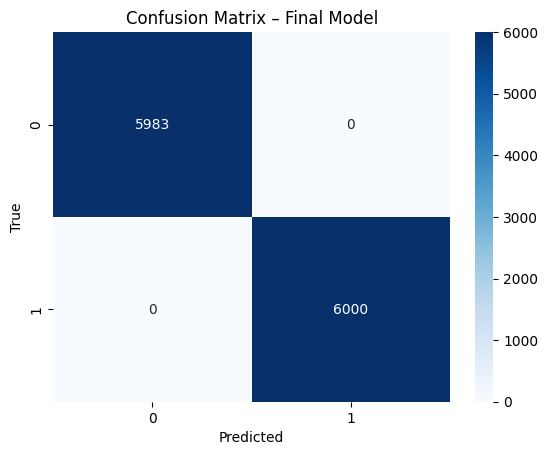

In [44]:
X_test_final = X_test_raw_df[best_feature]
y_pred_final = final_pipeline.predict(X_test_final)

print("Final Test Set Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_final, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix – Final Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
13B - Retrain on Full Dataset

Purpose: After unbiased test evaluation, retrain on all available labeled data before generating validation predictions.

Why: The test set has already served its purpose.
Using all available data may slightly improve the final model.
</div>

In [ ]:
"""
Retrain best model using all labeled data.

This step occurs AFTER test evaluation.
"""

X_full = data[best_feature]
y_full = data['label']

final_pipeline.fit(
    X_full,
    y_full
)

print("Final pipeline retrained on full dataset.")

# Save pipeline
with open("final_pipeline.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)

print("Pipeline saved.")

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
14- Feature Importance

Purpose: Inspect most predictive words for interpretability.

Why: Understand model behaviour.
</div>

In [45]:
if best_classifier in ['LogisticRegression', 'LinearSVC']:
    feature_names = final_pipeline.named_steps['tfidf'].get_feature_names_out()
    coefs = final_pipeline.named_steps['clf'].coef_[0]
    top_n = 20
    top_positive = np.argsort(coefs)[-top_n:]
    top_negative = np.argsort(coefs)[:top_n]
    print("Top real‑indicative words/phrases:")
    print([feature_names[i] for i in top_positive])
    print("\nTop fake‑indicative words/phrases:")
    print([feature_names[i] for i in top_negative])
else:
    print("Feature importance not available for this model.")

Feature importance not available for this model.


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
15- Predict on Validation Data

Purpose: Generate the final submission file.

Why: Required deliverable.
</div>

In [47]:
X_val = validation[best_feature]
val_pred = final_pipeline.predict(X_val)

submission = validation.copy()
submission['label'] = val_pred
submission = submission[['label', 'title', 'text', 'subject', 'date']]
submission.to_csv('../dataset/predictions.csv', index=False)
print("Predictions saved to '../dataset/predictions.csv'")

Predictions saved to '../dataset/predictions.csv'


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
16- Final Cross‑validation on Full Data

Purpose: Estimate generalisation performance.

Why: More robust than a single test split.
</div>

In [ ]:


cv_scores = cross_val_score(final_pipeline, X_full, y_full, cv=5, scoring='f1_weighted')
print(f"Cross‑validation F1 scores: {cv_scores}")
print(f"Mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross‑validation F1 scores: [0.99824759 0.99749656 0.98835717 0.9966199  0.99762143]
Mean F1: 0.9957 ± 0.0037
